# baccoemu for matter power spectrum model


Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Burger et al. (2025)...
/home/xantyos/venv/jax_env/lib/python3.12/site-packages/baccoemu/bispectrum_baryonic_boost/powerspectra_ratio_bcm_emu_folded.pkl
dict_keys(['n_parameters', 'parameters', 'feature_dimensions', 'scaling_division', 'scaling_subtraction', 'parameter_ranges', 'weights', 'hyper_params', 'param_train_mean', 'param_train_std', 'feature_train_mean', 'feature_train_std'])
Baryonic Emulator for matter powerspectrum Burger et al. (2025) loaded in memory.


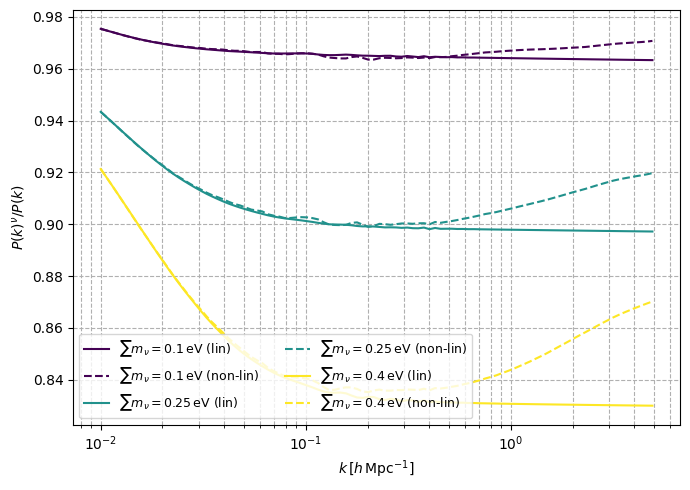

In [1]:
import baccoemu
import numpy as np
import matplotlib.pyplot as plt

params = {
    'omega_cold': 0.26067,
    'omega_baryon': 0.0488911 ,
    'hubble': 0.67742,
    'ns': 0.96822,
    'A_s': 2.1064e-9,
    'neutrino_mass': 0.0,
    'w0': -0.99,
    'wa': 0,
    'expfactor': 1
}

emulator = baccoemu.Matter_powerspectrum(baryonic_model_name='Burger2025')
k = np.logspace(-2, np.log10(4.9), num=100)

k, pk = emulator.get_linear_pk(k=k, cold=True, **params)
params_boost = params.copy()
params_boost.pop('A_s')  
params_boost['sigma8_cold'] = 0.8102  

# boost sans neutrinos
k_boost, Q0 = emulator.get_nonlinear_boost(
    k=k, cold=True, **params_boost
)

# spectre non-linéaire reconstruit
pknl = Q0 * pk

results_bacco = []

masses = [0.1, 0.25, 0.4]

colors = plt.cm.viridis(np.linspace(0, 1, len(masses)))
plt.figure(figsize=(7,5))

for mass, color in zip(masses, colors):
    params_nu = params.copy()
    params_nu['neutrino_mass'] = mass
    #params_nu['A_s'] = 2.1 *10 **(-9)
    # spectra
    k_nu, pk_nu = emulator.get_linear_pk(k=k, cold=True, **params_nu)
    params_boost_nu = params_boost.copy()
    params_boost_nu['neutrino_mass'] = mass

    k_boost, Q_nu = emulator.get_nonlinear_boost(
        k=k, cold=True,  **params_boost_nu
    )

    pknl_nu = Q_nu * pk_nu

    # LINEAR
    results_bacco.append({
        "k": k,
        "ratio": pk_nu / pk,
        "mass": mass,
        "method": "BACCO"
    })


    plt.semilogx(
        k, pk_nu/pk,
        linestyle='-',
        color=color,
        label=fr'$\sum m_\nu = {mass}\,\mathrm{{eV}}$ (lin)'
    )
    plt.semilogx(
        k, pknl_nu/pknl,
        linestyle='--',
        color=color,
        label=fr'$\sum m_\nu = {mass}\,\mathrm{{eV}}$ (non-lin)'
    )

plt.xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^{\nu} / P(k)$')
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

np.save("bacco_results.npy", results_bacco)